In [1]:
import os
import sys
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines  
from scipy.stats import gaussian_kde

PROJECT_PATH = os.path.abspath(os.path.join("..", ".."))
PIPELINE_PATH = os.path.join(PROJECT_PATH, "pipeline")
DATA_DIRECTORY = os.path.join(PROJECT_PATH, "data")

unflagged_data = False

if PIPELINE_PATH not in sys.path:
    sys.path.append(PIPELINE_PATH)

from utils.paths import DESPIKED_DATA_DIRECTORY
from utils.config_files import load_json_config
from utils.import_data import import_acropolis_site_data
from config.sites_deloyment_times import deployment_times

assert(os.path.exists(DESPIKED_DATA_DIRECTORY))

# load files
config = load_json_config("config.json")

In [2]:
# import all sites with column "site" added
df_sites = []

for site in config["icos_cities_portal"]["site_names"]:

    df_site = import_acropolis_site_data(target_directory=DESPIKED_DATA_DIRECTORY,
                                            deployment_times=deployment_times,
                                            site_name=site) \
            .filter(pl.col("Flag") == "U") \
            .select(["datetime", "gmp343_corrected", "sht45_humidity"]) \
            .with_columns(site = pl.lit(site)) \
            .with_columns(
            pl.col("datetime")
            .dt.convert_time_zone("Europe/Berlin")
            .alias("datetime_local")) \
            # .group_by_dynamic("datetime_local", every="1h") \
            # .agg(pl.mean("gmp343_corrected").alias("gmp343_corrected"))

    df_sites.append(df_site)
    
df = pl.concat(df_sites).filter(pl.col("gmp343_corrected") < 1000)

In [81]:
x = df["gmp343_corrected"].to_numpy()

# distribution
print(np.percentile(x, [2.5 , 97.5]))

[417.92 528.35]


In [82]:
def freedman_diaconis_bins(x: np.ndarray) -> int:
    """Robust bin count based on the Freedman-Diaconis rule."""
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    n = x.size
    if n < 2:
        return 10
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    if iqr == 0:
        return int(np.sqrt(n))
    bw = 2 * iqr * n ** (-1/3)
    if bw <= 0:
        return int(np.sqrt(n))
    bins = int(np.ceil((x.max() - x.min()) / bw))
    return max(bins, 10)

bins = freedman_diaconis_bins(x)
bins

3865

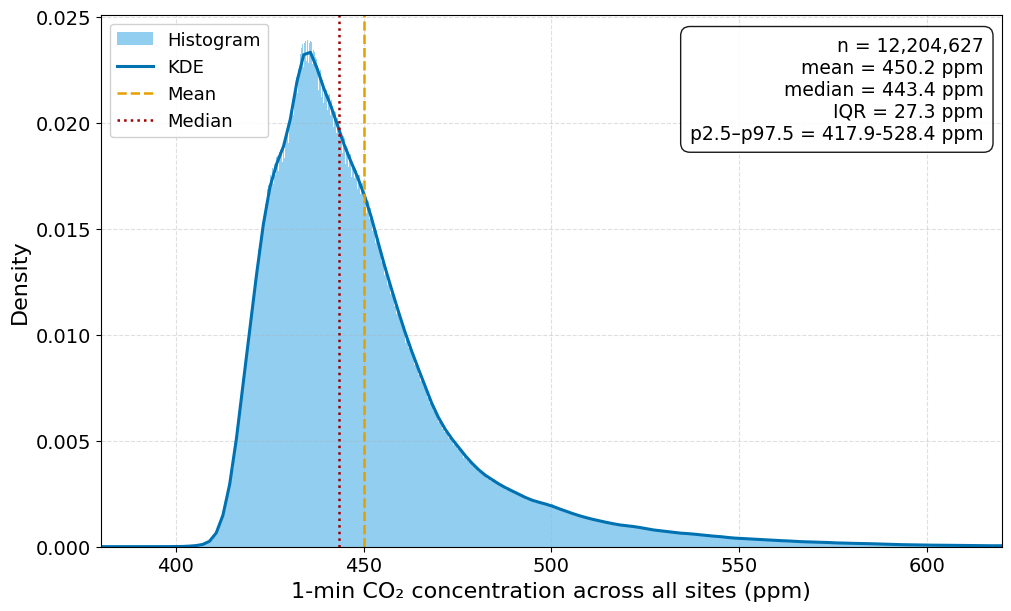

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# --- Colorblind-safe palette (Wong et al.) ---
PALETTE = {
    "hist":   "#56B4E9",  # sky blue
    "kde":    "#0072B2",  # blue
    "mean":   "#E69F00",  # orange
    "median": "#9E0000",  # red
    "text":   "#000000",  # black
}

def freedman_diaconis_bins(x: np.ndarray) -> int:
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    n = x.size
    if n < 2:
        return 10
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    if iqr <= 0:
        return max(10, int(np.sqrt(n)))
    bw = 2 * iqr * n ** (-1/3)
    if bw <= 0:
        return max(10, int(np.sqrt(n)))
    bins = int(np.ceil((x.max() - x.min()) / bw))
    return max(bins, 10)

# --- Data ---
show_kde = True
x = df["gmp343_corrected"].to_numpy()
x = x[np.isfinite(x)]
n = x.size

# --- Stats ---
mu = float(np.mean(x)) if n else np.nan
md = float(np.median(x)) if n else np.nan
iqr = float(np.percentile(x, 75) - np.percentile(x, 25)) if n else np.nan
p025, p975 = (np.percentile(x, 2.5), np.percentile(x, 97.5)) if n else (np.nan, np.nan)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

# Histogram (grayscale-friendly)
bins = freedman_diaconis_bins(x)
ax.hist(
    x, bins=bins, density=True, alpha=0.65,
    color=PALETTE["hist"], linewidth=0.5,
    label="Histogram"
)

# KDE (if enough data)
if show_kde and n > 10:
    kde = gaussian_kde(x)
    xs = np.linspace(x.min(), x.max(), 512)
    ax.plot(xs, kde(xs), linewidth=2.2, linestyle="-", color=PALETTE["kde"], label="KDE")

# Mean & median lines (distinct colors + linestyles)
ax.axvline(mu, linewidth=1.8, linestyle="--", color=PALETTE["mean"], label="Mean")
ax.axvline(md, linewidth=1.8, linestyle=":",  color=PALETTE["median"], label="Median")

# Annotation box (high contrast)
box_text = (
    f"n = {n:,.0f}\n"
    f"mean = {mu:.1f} ppm\n"
    f"median = {md:.1f} ppm\n"
    f"IQR = {iqr:.1f} ppm\n"
    f"p2.5-p97.5 = {p025:.1f}-{p975:.1f} ppm"
)
ax.text(
    0.98, 0.96, box_text, transform=ax.transAxes, ha="right", va="top",
    color=PALETTE["text"],
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black", alpha=0.9),
    fontsize=13.5
)

# Labels, grid, limits
ax.set_xlabel("1-min CO₂ concentration across all sites (ppm)", fontsize=16)
ax.set_ylabel("Density", fontsize=16)
ax.tick_params(axis="both", labelsize=14)
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xlim(380, 620)

# Legend with readable frame
leg = ax.legend(fontsize=13, frameon=True)
leg.get_frame().set_alpha(0.9)

plt.show()

In [6]:
x = df["sht45_humidity"].to_numpy()
np.percentile(x, [95, 5])

array([45.99146167, 15.92      ])

In [7]:
def freedman_diaconis_bins(x: np.ndarray) -> int:
    """Robust bin count based on the Freedman-Diaconis rule."""
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    n = x.size
    if n < 2:
        return 10
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    if iqr == 0:
        return int(np.sqrt(n))
    bw = 2 * iqr * n ** (-1/3)
    if bw <= 0:
        return int(np.sqrt(n))
    bins = int(np.ceil((x.max() - x.min()) / bw))
    return max(bins, 10)

bins = freedman_diaconis_bins(x)
bins

845

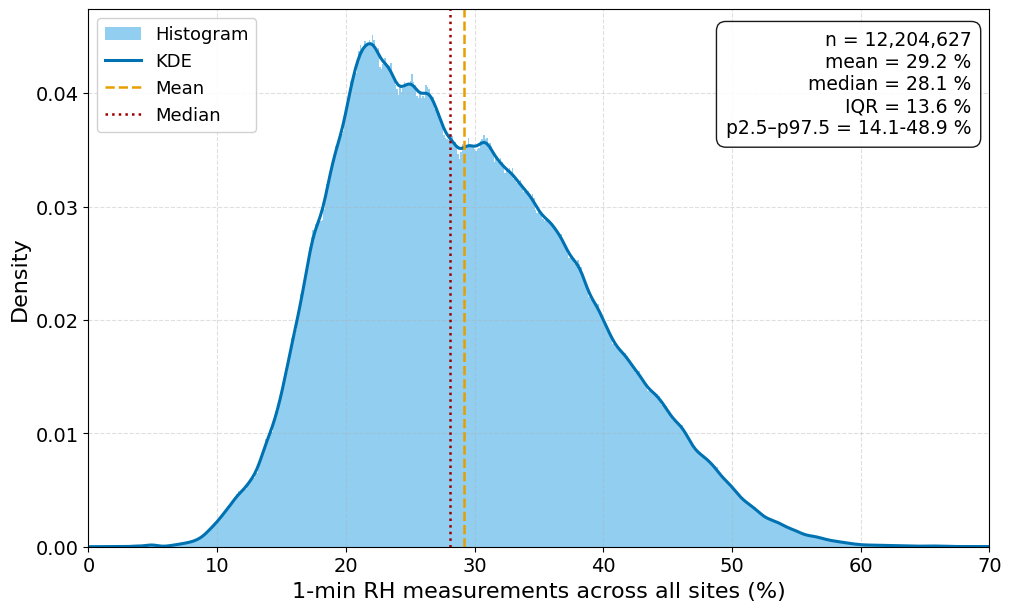

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# --- Colorblind-safe palette (Wong et al.) ---
PALETTE = {
    "hist":   "#56B4E9",  # sky blue
    "kde":    "#0072B2",  # blue
    "mean":   "#E69F00",  # orange
    "median": "#9E0000",  # red
    "text":   "#000000",  # black
}

def freedman_diaconis_bins(x: np.ndarray) -> int:
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    n = x.size
    if n < 2:
        return 10
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    if iqr <= 0:
        return max(10, int(np.sqrt(n)))
    bw = 2 * iqr * n ** (-1/3)
    if bw <= 0:
        return max(10, int(np.sqrt(n)))
    bins = int(np.ceil((x.max() - x.min()) / bw))
    return max(bins, 10)

# --- Data ---
show_kde = True
x = df["sht45_humidity"].to_numpy()
x = x[np.isfinite(x)]
n = x.size

# --- Stats ---
mu = float(np.mean(x)) if n else np.nan
md = float(np.median(x)) if n else np.nan
iqr = float(np.percentile(x, 75) - np.percentile(x, 25)) if n else np.nan
p025, p975 = (np.percentile(x, 2.5), np.percentile(x, 97.5)) if n else (np.nan, np.nan)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

# Histogram (grayscale-friendly)
bins = freedman_diaconis_bins(x)
ax.hist(
    x, bins=bins, density=True, alpha=0.65,
    color=PALETTE["hist"], linewidth=0.5,
    label="Histogram"
)

# KDE (if enough data)
if show_kde and n > 10:
    kde = gaussian_kde(x)
    xs = np.linspace(x.min(), x.max(), 512)
    ax.plot(xs, kde(xs), linewidth=2.2, linestyle="-", color=PALETTE["kde"], label="KDE")

# Mean & median lines (distinct colors + linestyles)
ax.axvline(mu, linewidth=1.8, linestyle="--", color=PALETTE["mean"], label="Mean")
ax.axvline(md, linewidth=1.8, linestyle=":",  color=PALETTE["median"], label="Median")

# Annotation box (high contrast)
box_text = (
    f"n = {n:,.0f}\n"
    f"mean = {mu:.1f} %\n"
    f"median = {md:.1f} %\n"
    f"IQR = {iqr:.1f} %\n"
    f"p2.5-p97.5 = {p025:.1f}-{p975:.1f} %"
)
ax.text(
    0.98, 0.96, box_text, transform=ax.transAxes, ha="right", va="top",
    color=PALETTE["text"],
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black", alpha=0.9),
    fontsize=13.5
)

# Labels, grid, limits
ax.set_xlabel("1-min RH measurements across all sites (%)", fontsize=16)
ax.set_ylabel("Density", fontsize=16)
ax.tick_params(axis="both", labelsize=14)
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xlim(0, 70)

# Legend with readable frame
leg = ax.legend(fontsize=13, frameon=True)
leg.get_frame().set_alpha(0.9)

plt.show()